In [48]:
import pandas as pd
from os.path import join
from os import listdir
import matplotlib.pyplot as plt

In [49]:
files = []
file_path = "/Users/carricarte/PhD/Projects/MARL-med/Repo/Multiagent_RL/scratch/metrics"
out_dir = "/Users/carricarte/PhD/Projects/MARL-med/Repo/Multiagent_RL/scratch/"
[files.append(join(file_path, file)) for file in listdir(file_path) if "sam_eval_metrics_" in file and file.endswith(".csv") and "._" not in file]
files.sort()

frame = []
for file in files:
    df = pd.read_csv(file)
    frame.append(df)
metrics_df = pd.concat(frame).reset_index(drop=True)
pass

In [56]:
print(f"Found {len(metrics_df['annotation'].unique())} unique masks")
print(f"with {sum(metrics_df['IoU'] <= 0.815)} challenging masks")
subset_df = metrics_df[metrics_df['IoU'] <= 0.815]

subset_df.to_csv(join(out_dir, 'challenging_masks.csv'), index=False, sep=';')

Found 1643591 unique masks
with 167856 challenging masks


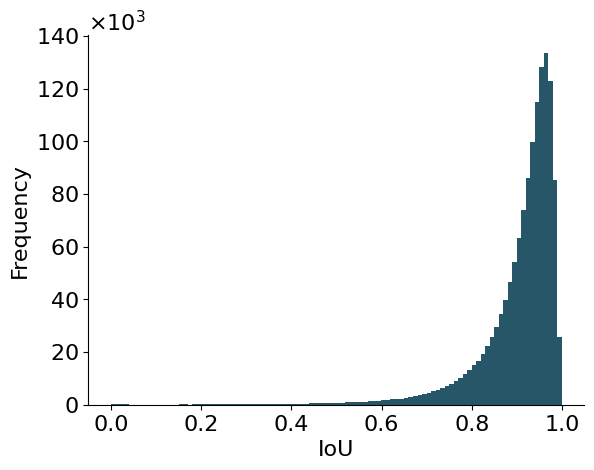

In [54]:
from matplotlib.ticker import ScalarFormatter

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 16

plt.hist(metrics_df['IoU'].unique(), bins=100, color="#285669")
# plt.axvline(x=0.815, color='#928477', linestyle='--', linewidth=2, label='Threshold = 0.815')
plt.xlabel('IoU')
plt.ylabel('Frequency')
# plt.legend(frameon=False)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Format y-axis to show values in thousands with ×10³ notation at the top
ax.ticklabel_format(style='sci', axis='y', scilimits=(3,3), useMathText=True)
ax.yaxis.get_offset_text().set_fontsize(16)

plt.savefig(join(out_dir, 'iou_histogram_no_legend.png'), dpi=330, bbox_inches='tight')
# plt.show()